# 0.0 Imports

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection

from sklearn import metrics as mt
from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn            import ensemble             as en
from sklearn            import linear_model         as lm

d:\Comunidade DS\Portifólio de Projetos\repos\ds_fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

## 0.2 Loading Data

In [3]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [4]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3583637,261,PAYMENT,858.71,C13713452,140843.67,139984.95,M875621857,0.0,0.0,0,0


# 1.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [6]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [9]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [10]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [12]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [13]:
cat_attributes.sample(5)

,type,name_orig,name_dest
4900700,PAYMENT,C1225017122,M444022833
1718957,CASH_OUT,C2067252200,C624330639
5254513,CASH_IN,C940401112,C982540411
6135979,TRANSFER,C1027462038,C925837478
5524826,PAYMENT,C1990585420,M1621909570


### 1.5.1 Numerical Attributes

In [14]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

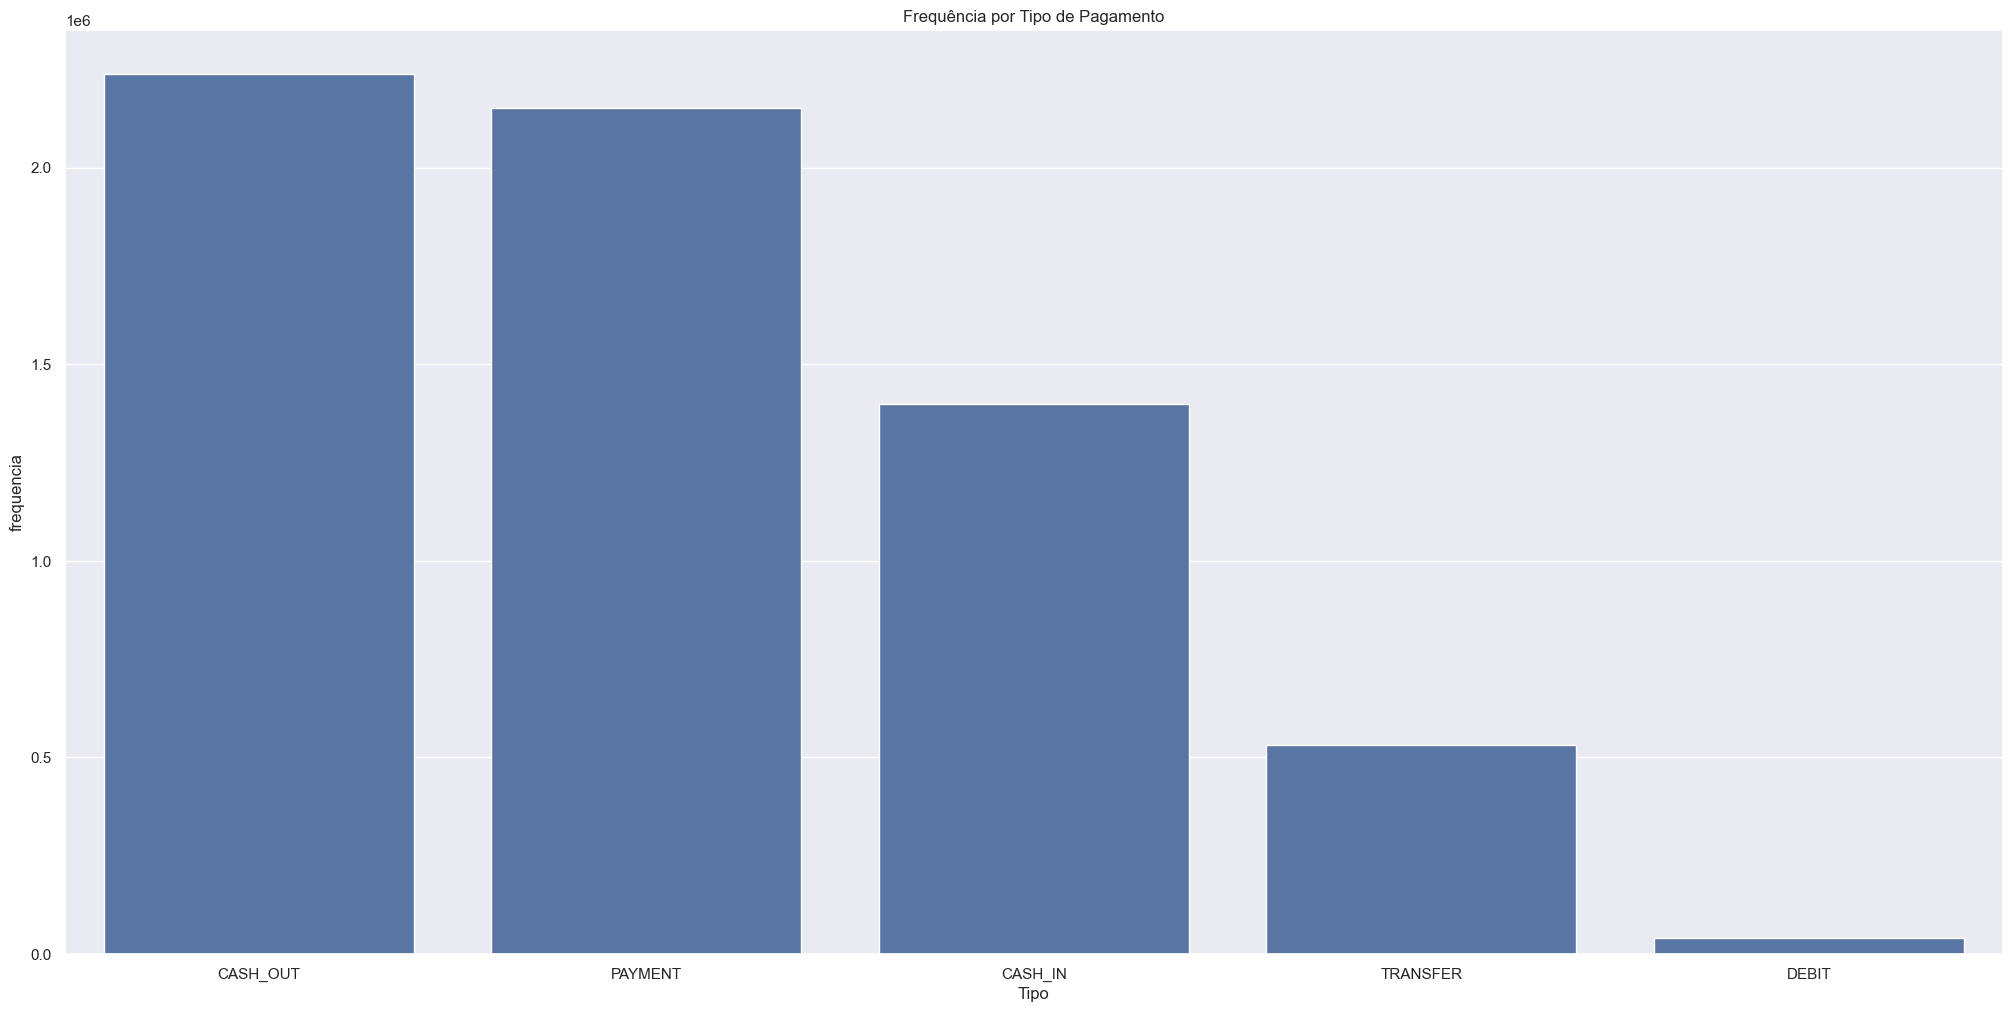

In [15]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

# 2.0 Feature Engineering

In [16]:
df2 = df1.copy()

In [17]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [18]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)

In [19]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [20]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


# 3.0 Filtragem de Variáveis

In [21]:
df3 = df2.copy()

In [22]:
df3.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
5164072,358,TRANSFER,37351.98,C1836065191,22853.0,0.0,C1075550972,229838.85,267190.83,0,0,15,22,Evening
2982610,231,TRANSFER,38195.64,C1723469776,13881.0,0.0,C1659712315,6880.72,45076.36,0,0,10,15,Afternoon
6150660,546,PAYMENT,16641.62,C853459289,0.0,0.0,M910990169,0.00,0.00,0,0,23,18,Evening
2281328,187,PAYMENT,34623.01,C1194841187,0.0,0.0,M1639968189,0.00,0.00,0,0,8,19,Evening
3107376,235,PAYMENT,8755.20,C648988826,25269.0,16513.8,M688239840,0.00,0.00,0,0,10,19,Evening


In [23]:
# Não existe nenhum cliente de origem do tipo Merchant
df_aux2 = df3[df3['name_dest'].str.contains(r'^M', na=False)]

In [24]:
# Não existe nenhuma transição de Merchant classificada como fraude
df_aux2[df_aux2['is_fraud'] == 1].shape

(0, 14)

In [25]:
df_aux = df3[df3['amount'] > 9000000]

In [26]:
df_aux.shape

(6335, 14)

In [27]:
df3_filtered = df3[(~df3['name_dest'].str.contains(r'^M', na=False)) & (df3['amount'] <= 8999999) ]

In [28]:
df3_filtered.shape

(4204790, 14)

In [29]:
num_attributes = df3_filtered.select_dtypes( include=['int64', 'float64'])
cat_attributes = df3_filtered.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

# 4.0 Análise Exploratória de Dados

In [30]:
df4 = df3_filtered.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

In [31]:
df_valid = df4[df4['is_fraud'] == 0]
df_fraud = df4[df4['is_fraud'] == 1]
df_flagged_fraud = df4[df4['is_flagged_fraud'] == 1] 


print(f'Quantidade de transações válidas: {df_valid.shape[0]}')
print(f'Quantidade de transações fraudulentas: {df_fraud.shape[0]}')
print(f'Quantidade de transações com flag de fraudulentas: {df_flagged_fraud.shape[0]}')

Quantidade de transações válidas: 4196921
Quantidade de transações fraudulentas: 7869
Quantidade de transações com flag de fraudulentas: 12


In [32]:
df_fraud['amount'].max()

np.float64(8994286.69)

In [33]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6008744,439,CASH_OUT,203119.08,C860758125,203119.08,0.0,C998349190,1163234.67,1366353.75,1,0,19,7,Morning
759791,38,TRANSFER,7567170.36,C1215509660,7567170.36,0.0,C96222488,0.00,0.00,1,0,2,14,Afternoon
1070137,125,CASH_OUT,99793.90,C1996420000,99793.90,0.0,C987180793,209608.93,309402.83,1,0,6,5,Morning
6020327,462,CASH_OUT,167743.93,C1955616732,167743.93,0.0,C1170488365,219716.29,387460.22,1,0,20,6,Morning
1030337,58,TRANSFER,561948.38,C856217790,561948.38,0.0,C1278181974,0.00,0.00,1,0,3,10,Morning
3193228,248,CASH_OUT,26776.98,C2049622163,26776.98,0.0,C1134158850,0.00,26776.98,1,0,11,8,Morning
3208638,249,CASH_OUT,369448.20,C2020495090,369448.20,0.0,C650699445,0.00,369448.20,1,0,11,9,Morning
6292295,664,CASH_OUT,639991.03,C1750763630,639991.03,0.0,C2000520198,0.00,639991.03,1,0,28,16,Afternoon
6021371,468,CASH_OUT,652782.54,C1743463751,652782.54,0.0,C400200038,170737.43,823519.97,1,0,20,12,Afternoon
6117482,529,TRANSFER,1399724.98,C1420554412,1399724.98,0.0,C424524612,0.00,0.00,1,0,23,1,Night


In [34]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1,27,22,Evening
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1,11,10,Morning
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1,25,10,Morning
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1,26,17,Afternoon
6362462,730,TRANSFER,7316255.05,C1869569059,17316255.05,17316255.05,C1861208726,0.0,0.0,1,1,31,10,Morning
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1,17,3,Night
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1,28,23,Evening
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1,9,20,Evening
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.0,0.0,1,1,31,21,Evening
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1,12,15,Afternoon


In [35]:
df_test = df4[df4['amount'] >= 200000]

In [36]:
df_test.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
5377422,376,TRANSFER,5398601.65,C1044414324,95888.00,0.0,C1429430502,0.00,5398601.65,0,0,16,16,Afternoon
5046796,354,TRANSFER,752855.93,C1958462352,0.00,0.0,C1506916666,4958917.00,5711772.92,0,0,15,18,Evening
5404115,377,CASH_OUT,251584.86,C230941114,70826.00,0.0,C301103726,0.00,251584.86,0,0,16,17,Afternoon
5519625,380,CASH_OUT,507531.90,C614172875,0.00,0.0,C992483683,4047318.71,4554850.61,0,0,16,20,Evening
6141567,545,CASH_OUT,250767.72,C2119137097,5245.37,0.0,C1845943287,260755.81,511523.53,0,0,23,17,Afternoon


### 4.1.2 Numerical Attributes

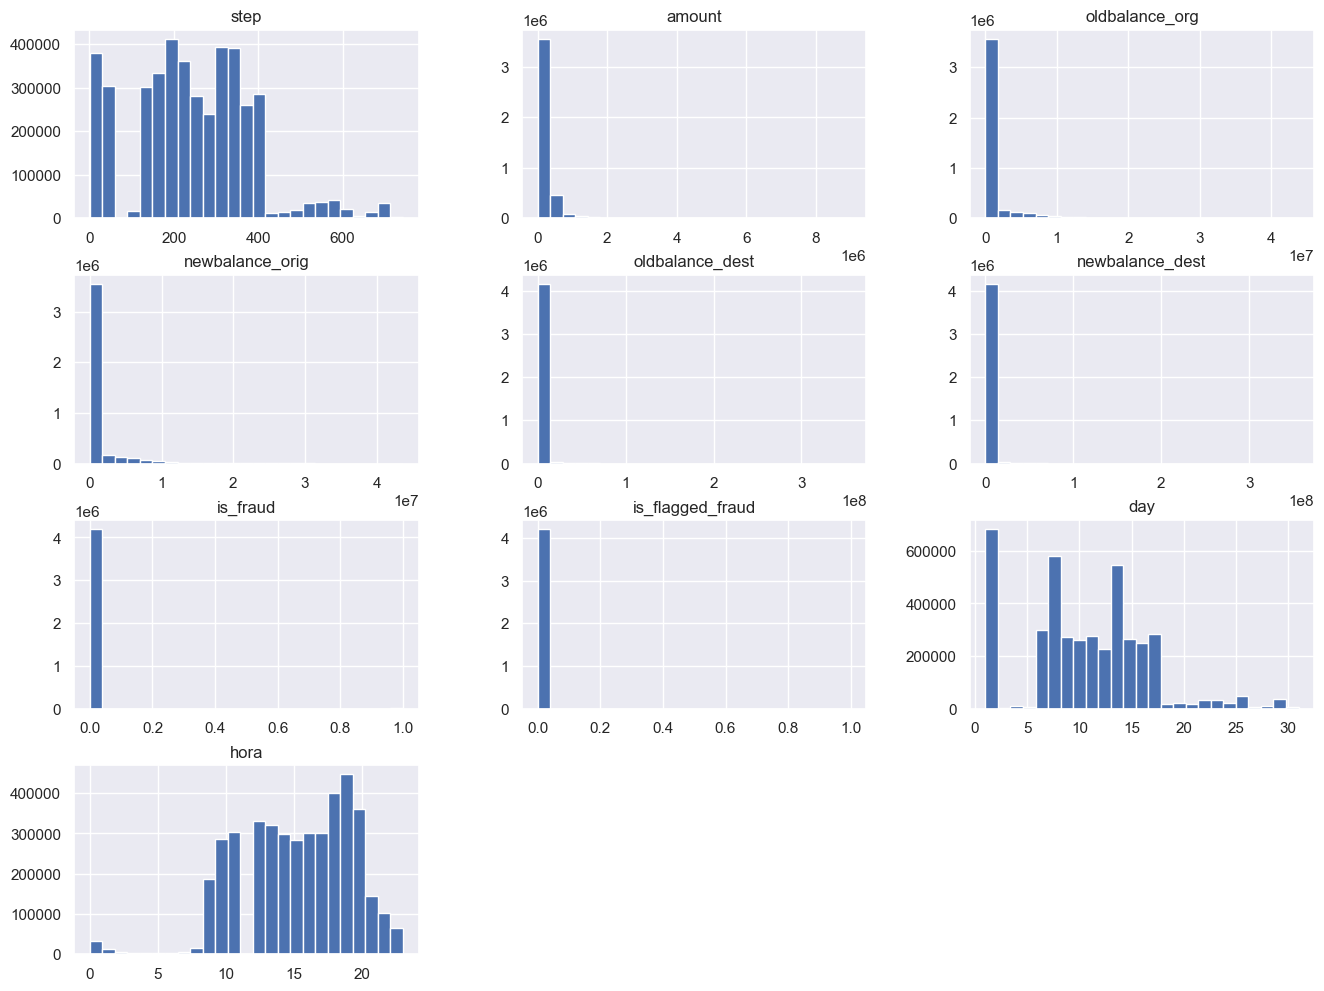

In [37]:
num_attributes.hist(bins= 25, figsize=(16,12));

### 4.1.2 Categorical Variables

<Axes: xlabel='count', ylabel='type'>

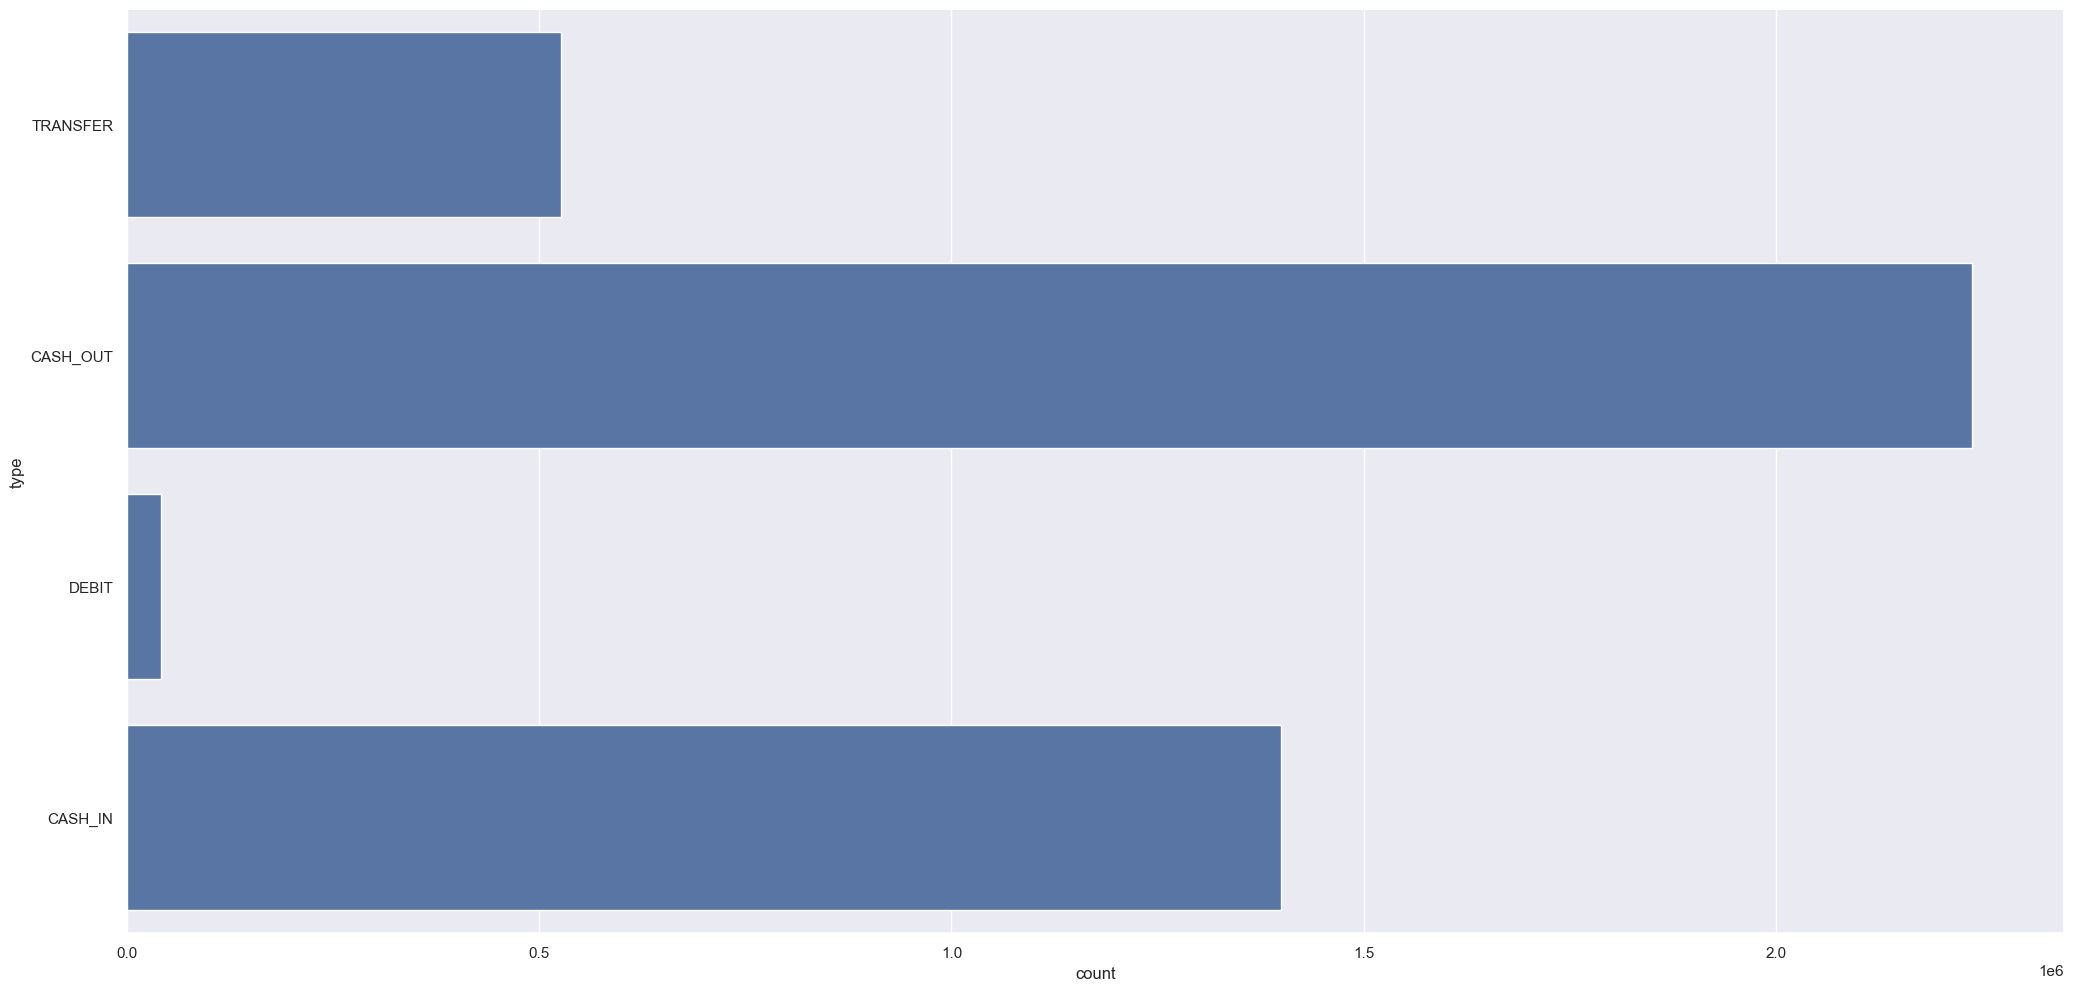

In [38]:
sns.countplot (df4['type'])

## 4.2 Analise Bivariada

In [39]:
df4.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud', 'day', 'hora', 'period_of_day'],
      dtype='object')

<Axes: xlabel='type', ylabel='is_fraud'>

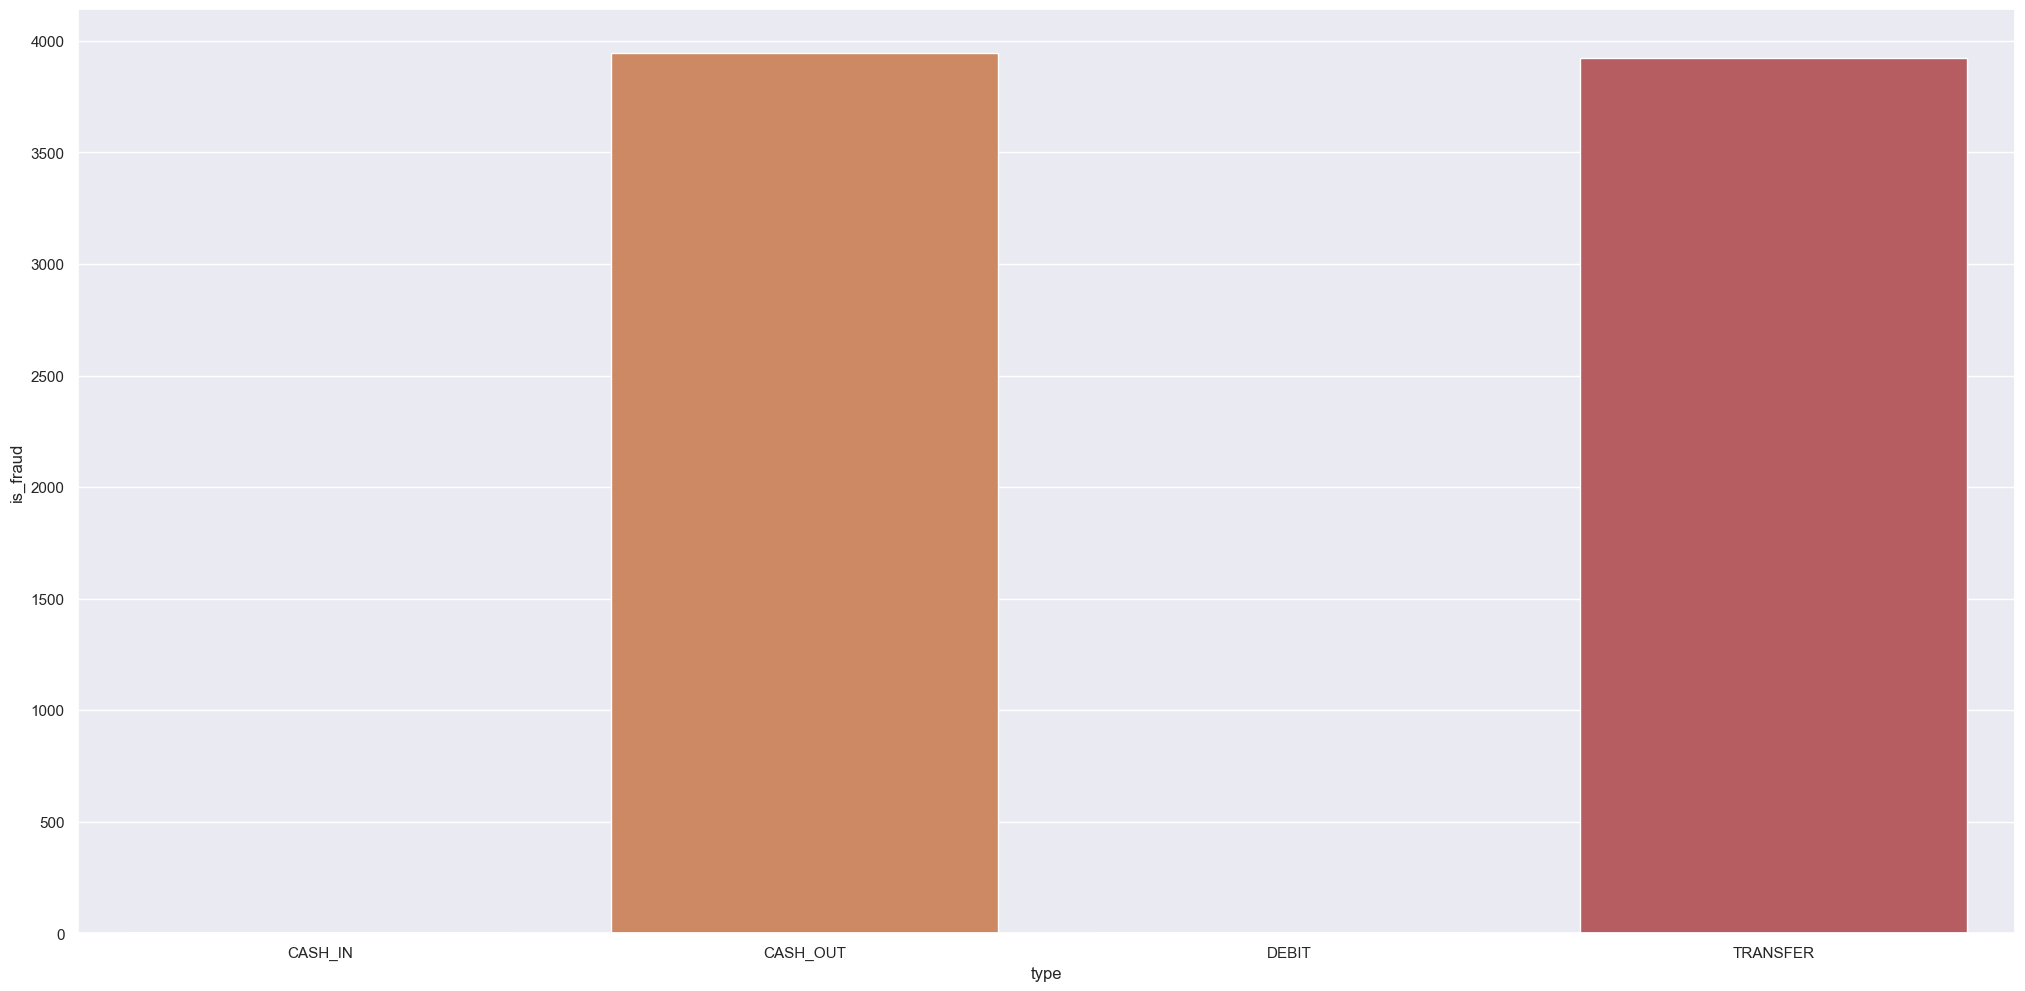

In [40]:
# Tipos de Transações que mais são fraudes

aux1 = df4[['type', 'is_fraud']].groupby('type').sum().reset_index()

sns.barplot( x='type', y='is_fraud', data=aux1, hue='type')

<Axes: xlabel='period_of_day', ylabel='is_fraud'>

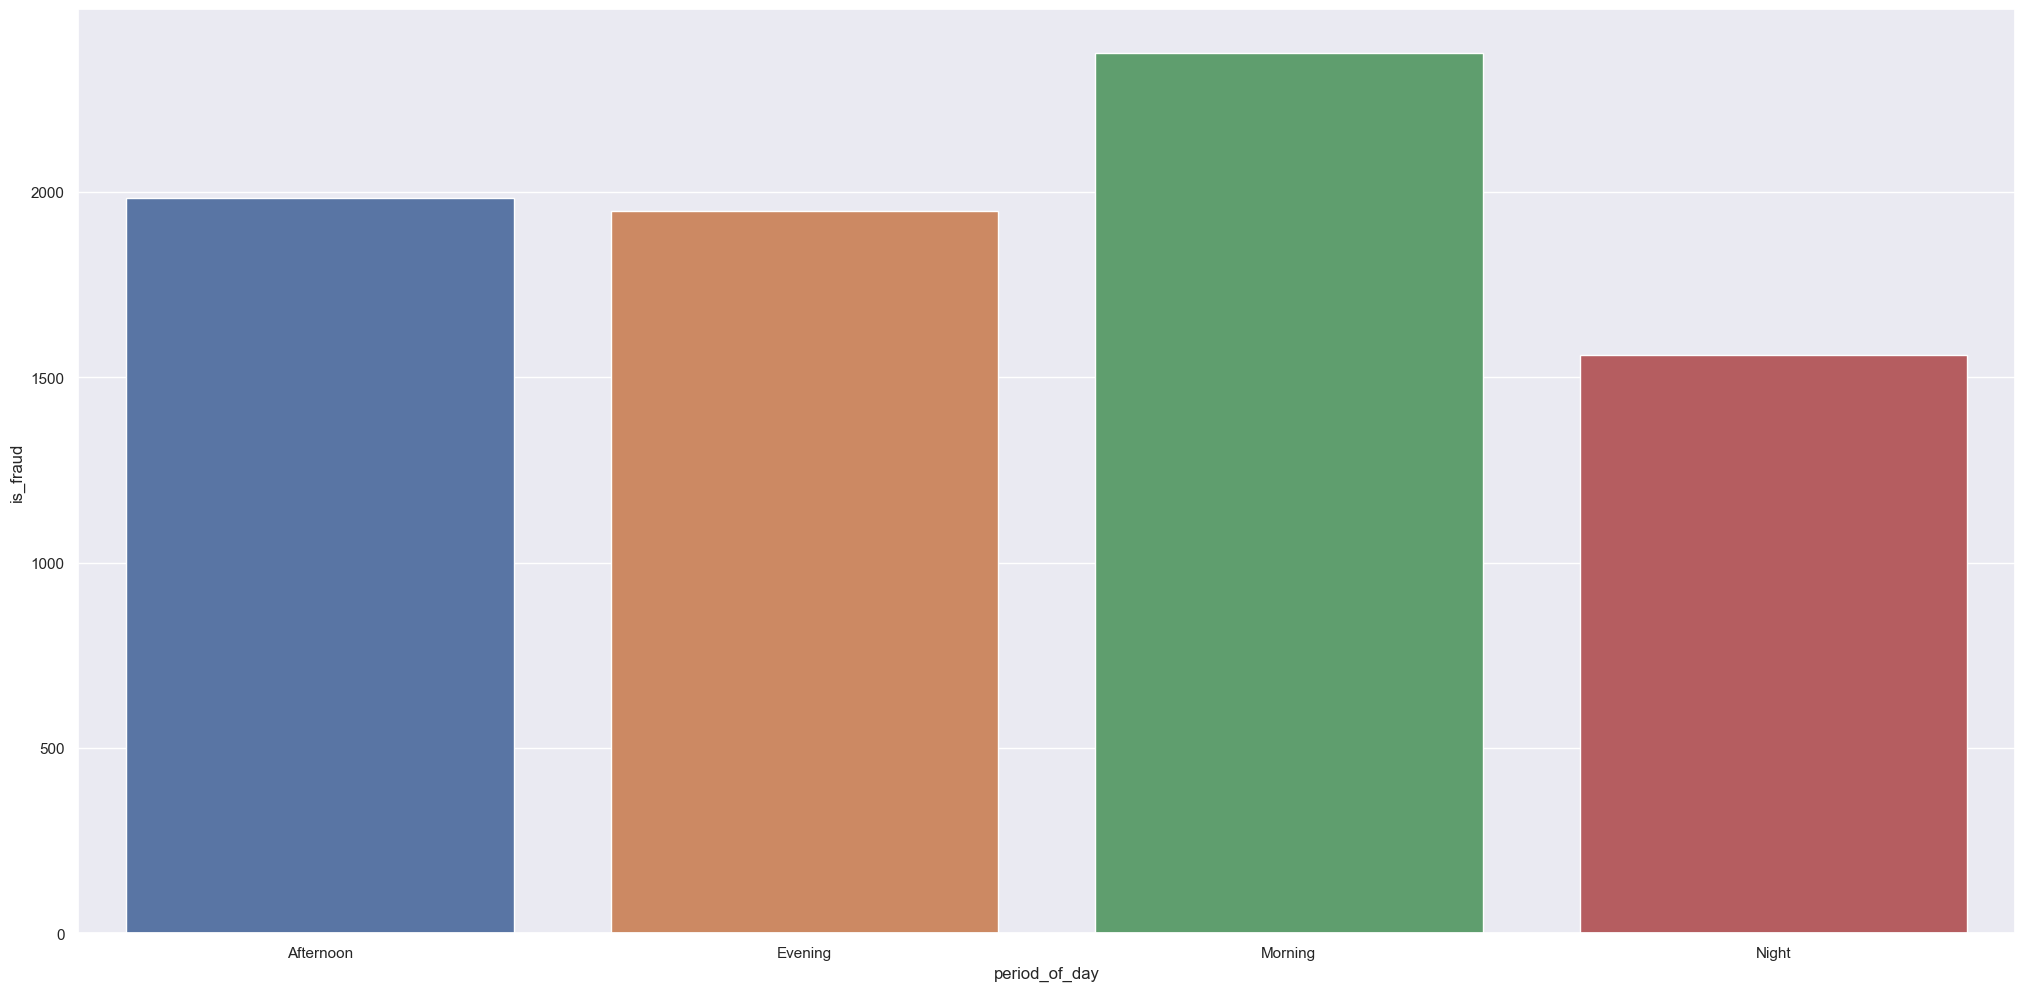

In [41]:
# Periodo do dia que mais ocorrem fraudes

aux1 = df4[['period_of_day', 'is_fraud']].groupby('period_of_day').sum().reset_index()

sns.barplot( x='period_of_day', y='is_fraud', data=aux1, hue='period_of_day')

In [42]:
df4.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night
10,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night


In [43]:
# Quantidade de transações fraudulentas no qual o total enviado é igual ao valor total da conta
aux2 = df4[df4['amount'] == df4['oldbalance_org']]

aux2.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,1,1,Night
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,1,1,Night
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,1,1,Night
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,1,1,Night
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,1,1,Night


In [44]:
# Quantidade de transações válidas: 4196921
# Quantidade de transações fraudulentas: 7869
# Quantidade de transações com flag de fraudulentas: 12

In [45]:
aux2.shape

(7836, 14)

In [46]:
# As transações que são fraudes, geralmente são aquelas transações que "limpam" o valor da conta do cliente.

In [ ]:
# Não existe clientes que fizeram mais de uma transação fraudulenta
fraude_por_cliente = df4[df4['is_fraud'] == 1].groupby('name_orig').size().reset_index(name='fraude_total')

In [48]:
df_fraud_aux = df4.merge(fraude_por_cliente, on='name_orig', how='left')

In [49]:
df_fraud_aux['fraude_total'] = df_fraud_aux['fraude_total'].fillna(0)
df_fraud_aux.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,fraude_total
0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night,1.0
1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night,1.0
2,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night,0.0
3,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night,0.0
4,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night,0.0


<Axes: xlabel='fraude_total', ylabel='count'>

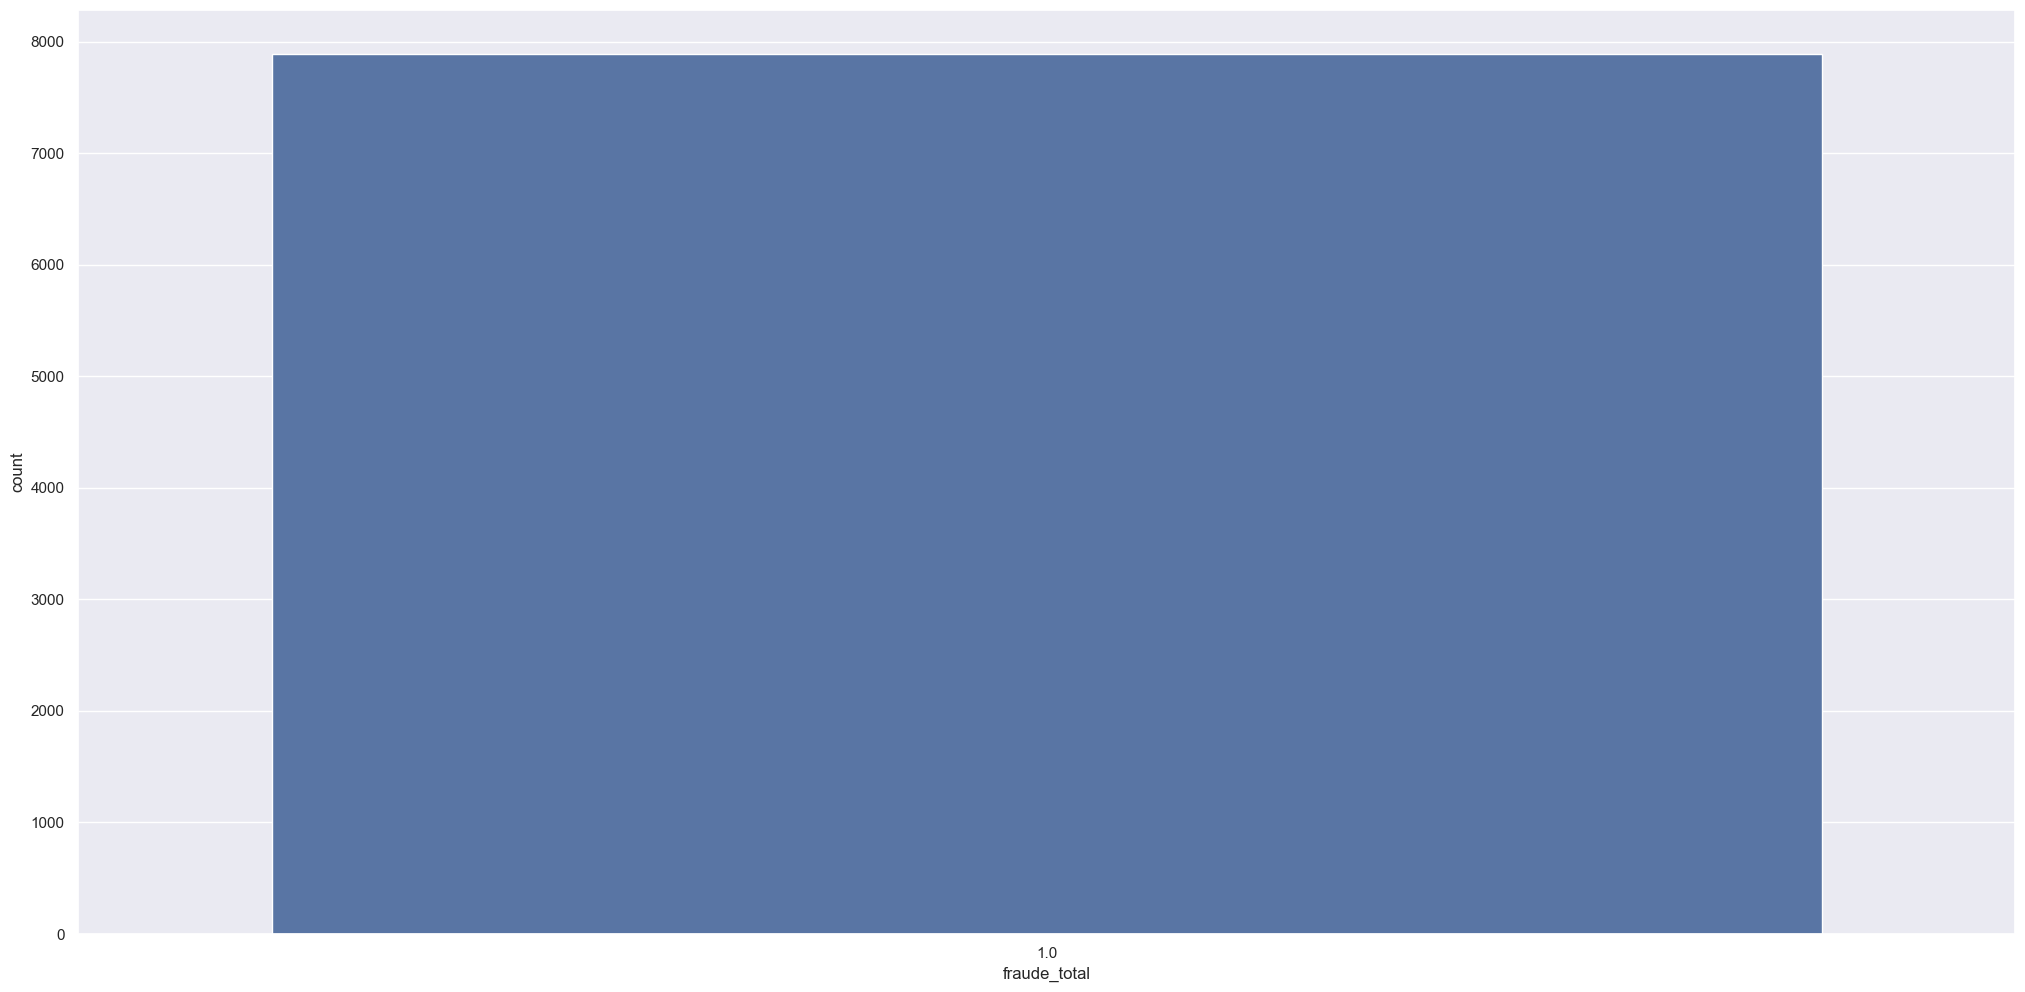

In [51]:

sns.countplot(data=df_fraud_aux[df_fraud_aux['fraude_total'] > 0], x='fraude_total')

## 4.3 Análise Multivariada

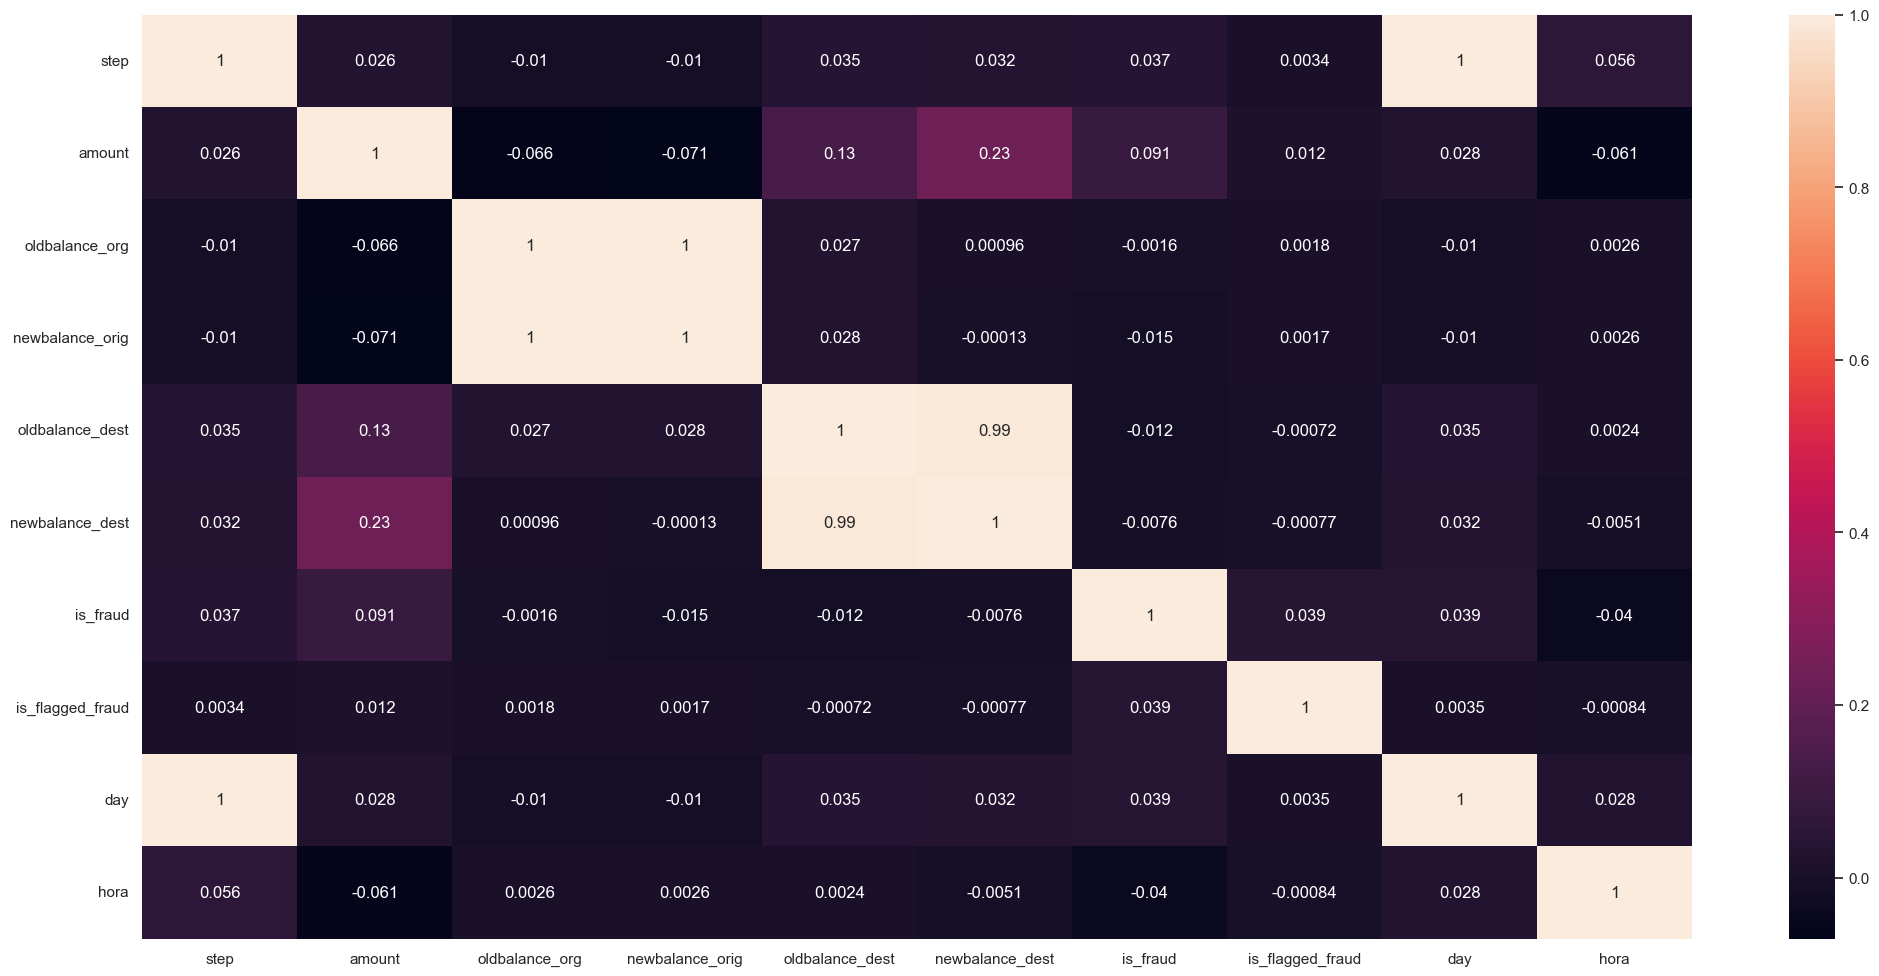

In [ ]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);

# 5.0 Data Preparation

In [64]:
df5 = df4.copy()

## 5.1 Transformation

In [65]:
# 0 => $0.1
eps = 0.001 

df5['amount'] = np.log(df5.pop('amount')+eps)
df5['oldbalance_org'] = np.log(df5.pop('oldbalance_org')+eps)
df5['newbalance_orig'] = np.log(df5.pop('newbalance_orig')+eps)
df5['oldbalance_dest'] = np.log(df5.pop('oldbalance_dest')+eps)
df5['newbalance_dest'] = np.log(df5.pop('newbalance_dest')+eps)

### 5.1.1 Encoding

In [79]:
df5 = pd.get_dummies(df5, prefix=['type'], columns=['type'])

## 5.2 Train Test Validation Split

In [80]:
train, test = train_test_split(df5, test_size=0.2, random_state=42, stratify=df5['is_fraud'])
train, val = train_test_split(train, test_size=0.2, random_state=42, stratify=train['is_fraud'])

In [81]:
print("Distribuição original:")
print(df5['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no treino:")
print(train['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no teste:")
print(test['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no teste:")
print(val['is_fraud'].value_counts(normalize=True))

Distribuição original:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no treino:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998128
1    0.001872
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64


## 5.1 Transformation

### 5.1.1 One Hot Encoding

# 6.0 Feature Selection

In [92]:
df6 = train.copy()

In [93]:
df6_val = val.copy()

In [94]:
df6.columns

Index(['step', 'name_orig', 'name_dest', 'is_fraud', 'is_flagged_fraud', 'day',
       'hora', 'period_of_day', 'amount', 'oldbalance_org', 'newbalance_orig',
       'oldbalance_dest', 'newbalance_dest', 'type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_TRANSFER'],
      dtype='object')

In [95]:
cols_drop = ['name_orig', 'name_dest', 'period_of_day']
df6 = df6.drop(cols_drop, axis=1)
df6_val = df6_val.drop(cols_drop, axis=1)


In [96]:
X_train = df6.copy()
y_train = X_train['is_fraud']
X_train  = X_train.drop('is_fraud', axis=1)

X_train_val = df6_val.copy()
y_train_val = X_train_val['is_fraud']
X_train_val  = X_train_val.drop('is_fraud', axis=1)

# 7.0 Machine Learning Modeling

## 7.1 Random Forest Classifier

In [123]:
#define

rfc = en.RandomForestClassifier(max_depth=15, n_estimators=50, class_weight='balanced', criterion='log_loss')

# train

rfc.fit(X_train, y_train)

# performace 

y_hat_test = rfc.predict_proba(X_train_val)

# acc = mt.accuracy_score(y_train_val, y_hat_test)

# precision = mt.precision_score(y_train_val, y_hat_test)

# recall = mt.recall_score(y_train_val, y_hat_test)

# f1_score = mt.f1_score(y_train_val, y_hat_test)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')


In [ ]:
yhat_test2 = y_hat_test[:,1]

672767

In [126]:
yhat_test2

array([0.        , 0.01010503, 0.00362855, ..., 0.00839929, 0.        ,
       0.00287307])

In [ ]:
th = 0.65
yhat_test = [1 if i > th else 0 for i in yhat_test2]

In [130]:
acc = mt.accuracy_score(y_train_val, yhat_test)

precision = mt.precision_score(y_train_val, yhat_test)

recall = mt.recall_score(y_train_val, yhat_test)

f1_score = mt.f1_score(y_train_val, yhat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.998867364184034
Precision: 0.6485355648535565
Recall: 0.8617950754567116
F1-Score: 0.7401091405184175


In [120]:
fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

Text(0, 0.5, 'True Positive Rate')

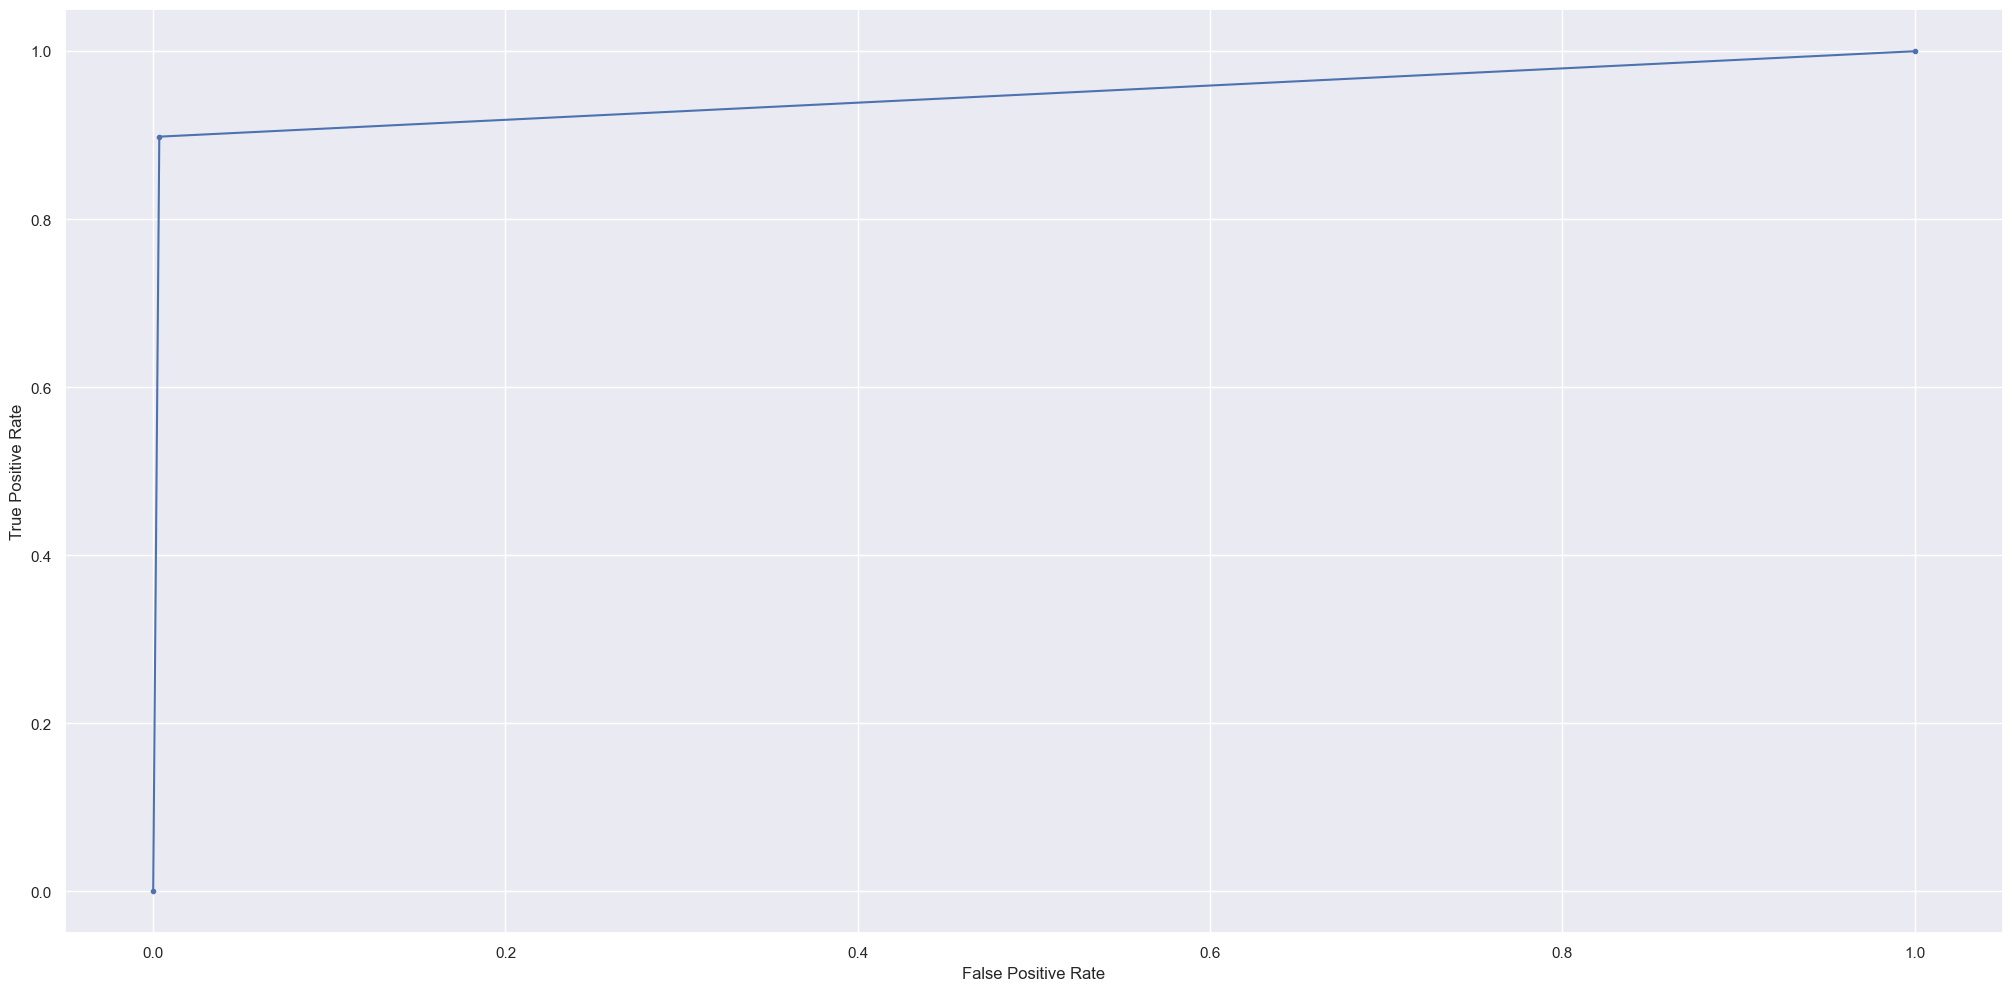

In [121]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

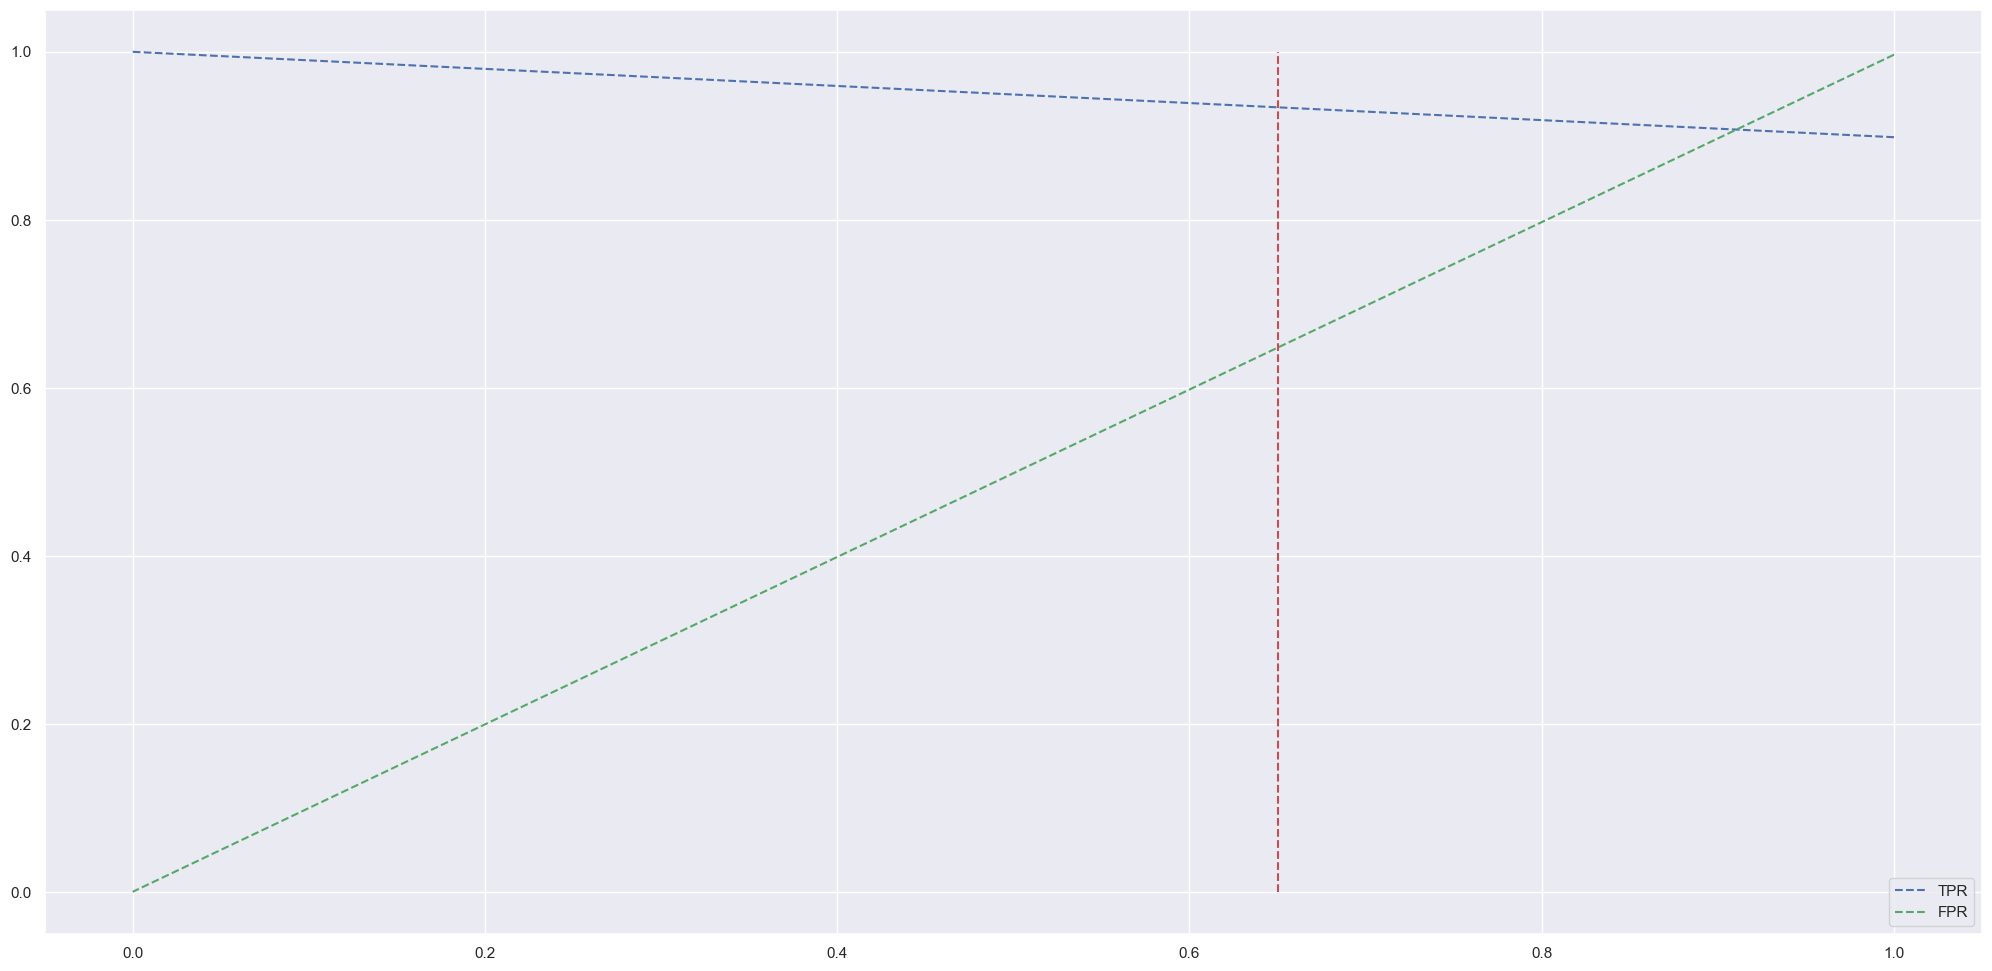

In [122]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
plt.legend()

## 7.2 Logistic Regression

In [117]:
# definition

lr = lm.LogisticRegression(max_iter=1000, class_weight='balanced')

# training (fit)

lr.fit(X_train, y_train)

# performace

y_hat_test = rfc.predict(X_train_val)

acc = mt.accuracy_score(y_train_val, y_hat_test)
precision = mt.precision_score(y_train_val, y_hat_test)
recall = mt.recall_score(y_train_val, y_hat_test)
f1_score = mt.f1_score(y_train_val, y_hat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9963494047716371
Precision: 0.3269731136166522
Recall: 0.8983320095313742
F1-Score: 0.4794404408647732


In [118]:
fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

Text(0, 0.5, 'True Positive Rate')

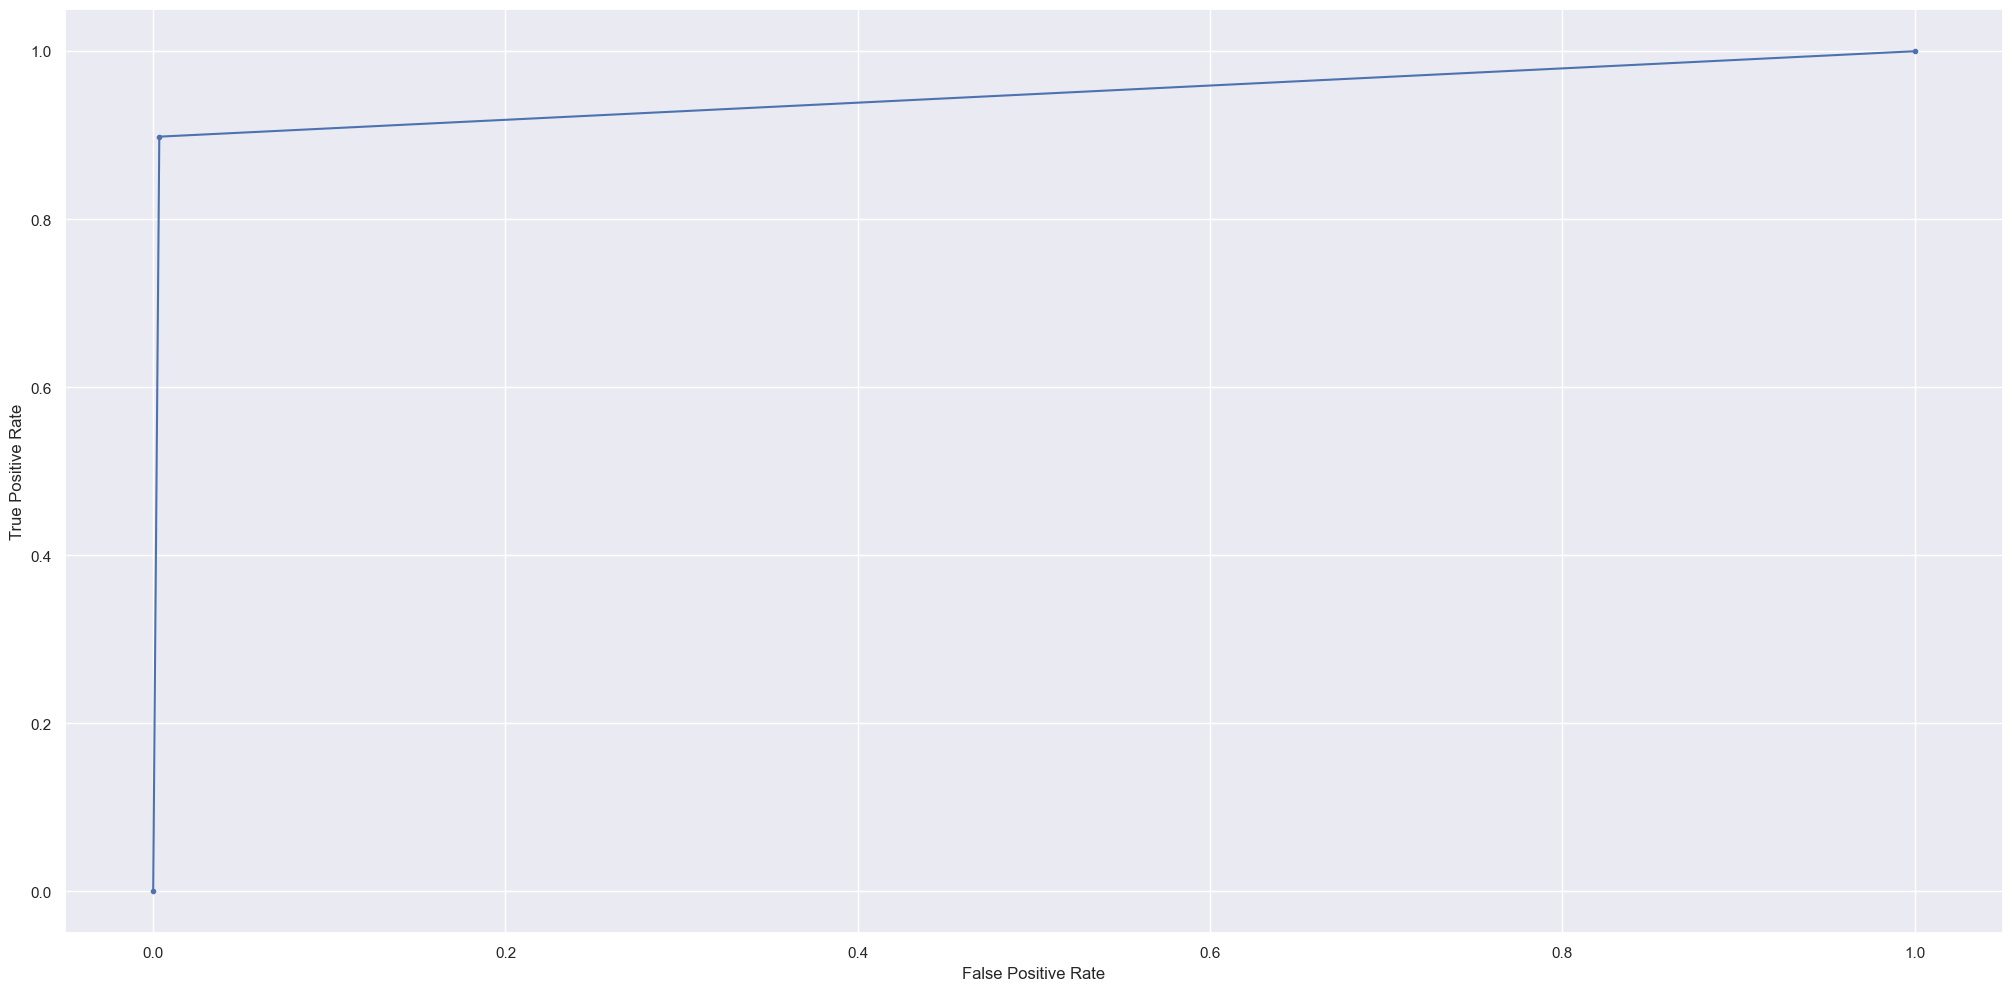

In [119]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

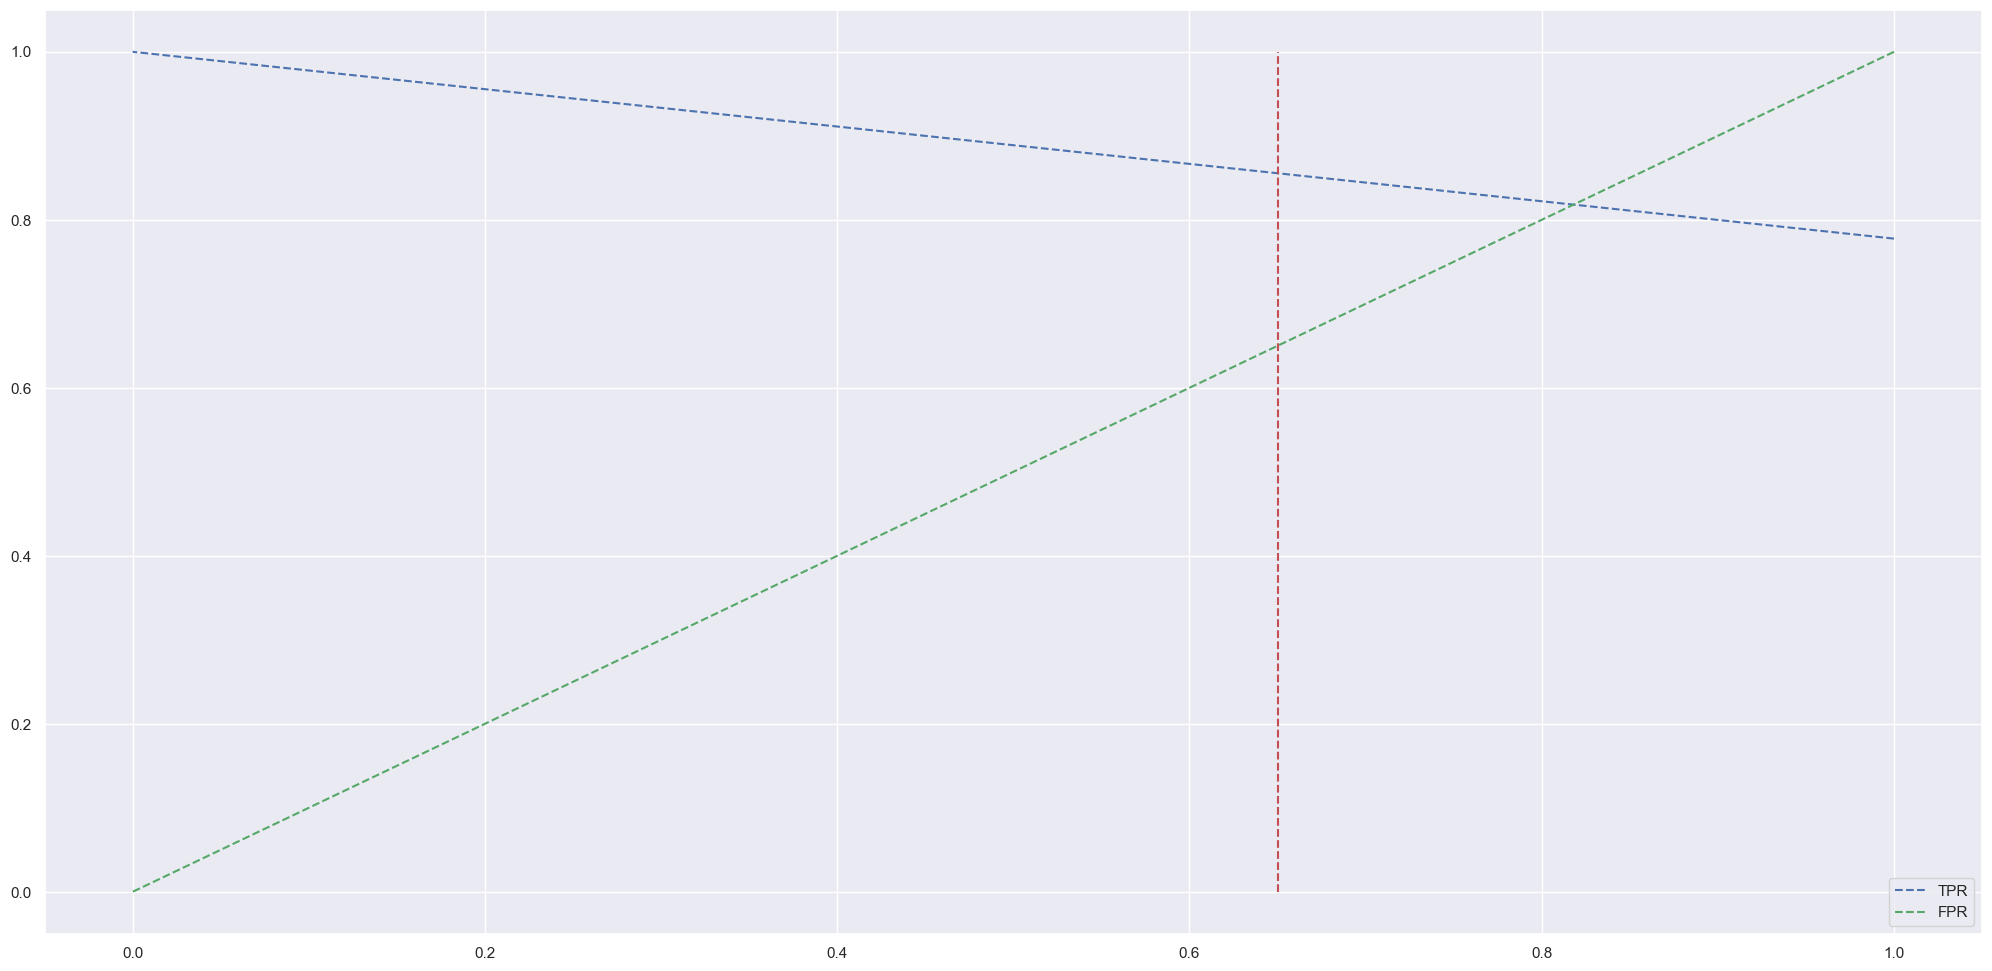

In [112]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
plt.legend()

# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model